###  Customer Segmentation Using Unsupervised Learning   


#### Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

#### Step 2: Load Dataset

In [19]:
df = pd.read_csv(r"C:\Users\arft\Downloads\Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Step 3: Check Dataset Shape

In [21]:
df.columns


Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [22]:
df.shape

(200, 5)

#### Step 5: Dataset Information

In [23]:
df.info

<bound method DataFrame.info of      CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]>

#### Step 6: Missing Values

In [26]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

#### Step 7: Summary Statistics

In [27]:
df.duplicated().sum()

np.int64(0)

#### Step 9: Gender Distribution


In [29]:
df["Genre"].value_counts()

Genre
Female    112
Male       88
Name: count, dtype: int64

#### Visualization

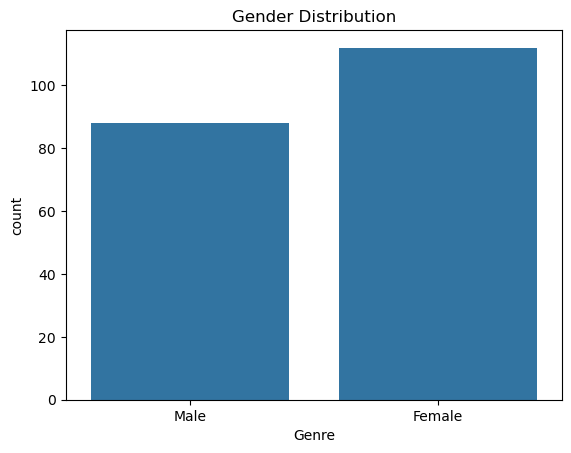

In [30]:
sns.countplot(x="Genre", data=df)

plt.title("Gender Distribution")

plt.show()

#### Step 10: Age Distribution

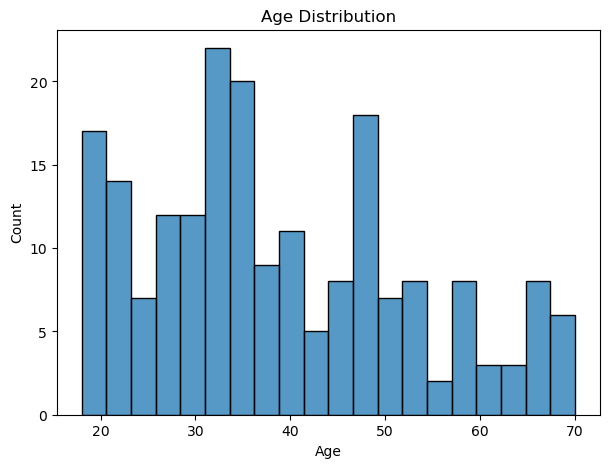

In [31]:
plt.figure(figsize=(7,5))

sns.histplot(df["Age"], bins=20)

plt.title("Age Distribution")

plt.show()

#### Step 11: Annual Income Distribution

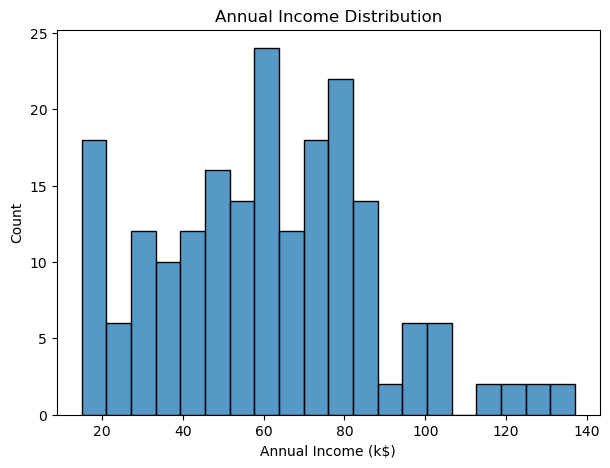

In [32]:
plt.figure(figsize=(7,5))

sns.histplot(df["Annual Income (k$)"], bins=20)

plt.title("Annual Income Distribution")

plt.show()

#### Step 12: Spending Score Distribution

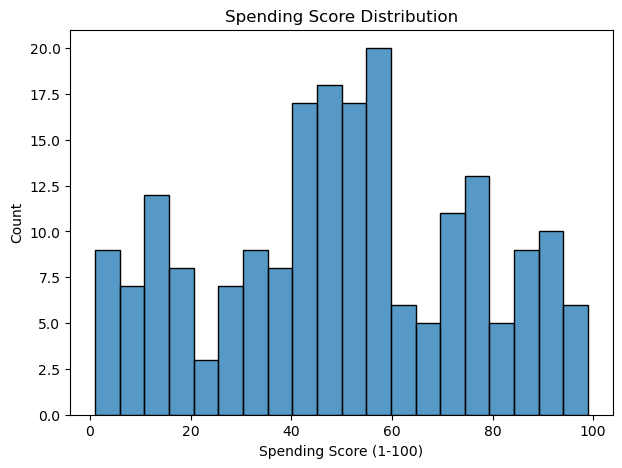

In [33]:
plt.figure(figsize=(7,5))

sns.histplot(df["Spending Score (1-100)"], bins=20)

plt.title("Spending Score Distribution")

plt.show()

#### Step 13: Correlation Heatmap

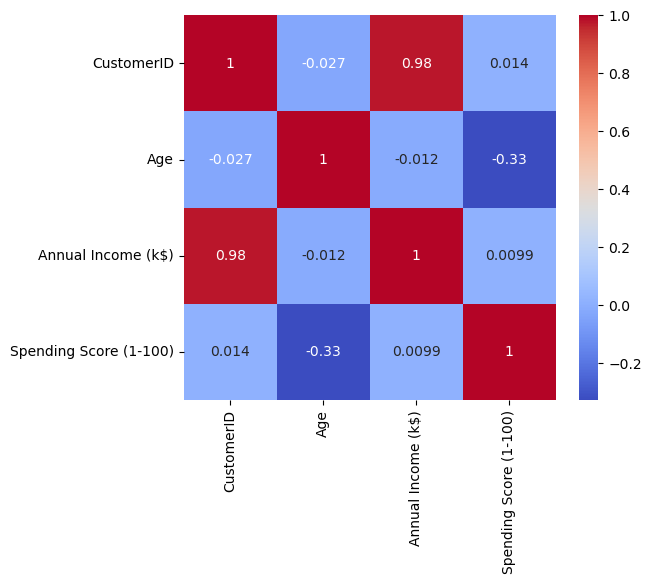

In [34]:
plt.figure(figsize=(6,5))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

#### Step 14: Pairplot

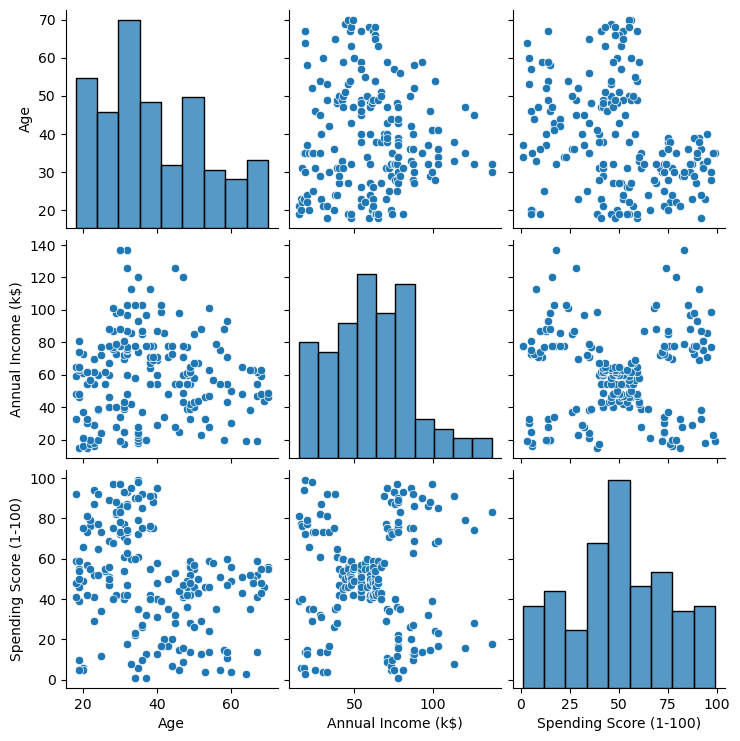

In [35]:
sns.pairplot(
df[["Age",
"Annual Income (k$)",
"Spending Score (1-100)"]]
)

plt.show()

#### Step 15: Boxplots (Outlier Check)

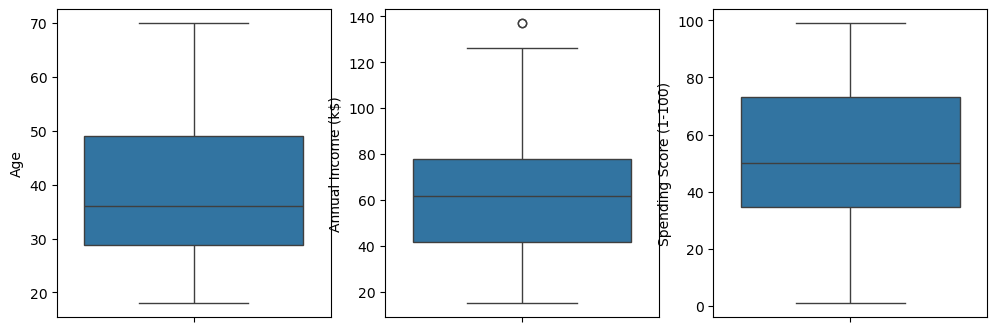

In [36]:
plt.figure(figsize=(12,4))

plt.subplot(131)
sns.boxplot(y=df["Age"])

plt.subplot(132)
sns.boxplot(y=df["Annual Income (k$)"])

plt.subplot(133)
sns.boxplot(y=df["Spending Score (1-100)"])

plt.show()

#### Step 16: Feature Selection

In [38]:
X = df[[
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

#### Step 17: Feature Scaling

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#### Step 18: Elbow Method 

C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

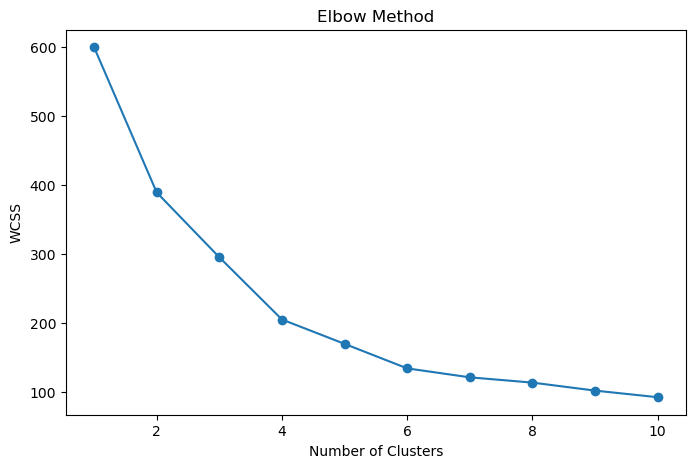

In [40]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

##### Insight
In the graph, the point where the bend (elbow) appears indicates the optimal number of clusters. For the Mall Customers dataset,
K = 5 is usually considered the best choice.

#### Step 19: Silhouette Score

In [41]:
for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={i}  Silhouette Score={score:.3f}")

K=2  Silhouette Score=0.335
K=3  Silhouette Score=0.358
K=4  Silhouette Score=0.404
K=5  Silhouette Score=0.408
K=6  Silhouette Score=0.431
K=7  Silhouette Score=0.410
K=8  Silhouette Score=0.367
K=9  Silhouette Score=0.374
K=10  Silhouette Score=0.362


C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

##### Insight
We choose the value of K with the highest score (typically K = 5 in most cases).

#### Step 20: Apply K-Means

In [42]:
kmeans = KMeans(n_clusters=5, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

C:\Users\arft\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


##### Now a new column named “Cluster” will be added to the dataset.

#### Step 21: Cluster Count

In [43]:
df["Cluster"].value_counts()

Cluster
0    58
3    45
1    40
4    31
2    26
Name: count, dtype: int64

#### Step 22: Cluster Summary

In [44]:
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

cluster_summary

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,68.775862,55.275862,47.620690,41.706897
1,161.025000,32.875000,86.100000,81.525000
2,23.461538,25.769231,26.115385,74.846154
3,86.377778,26.733333,54.311111,40.911111
4,166.870968,44.387097,89.774194,18.483871


#### Step 23: PCA Visualization

In [45]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

df["PCA1"] = pca_features[:,0]
df["PCA2"] = pca_features[:,1]

#### Scatter Plot

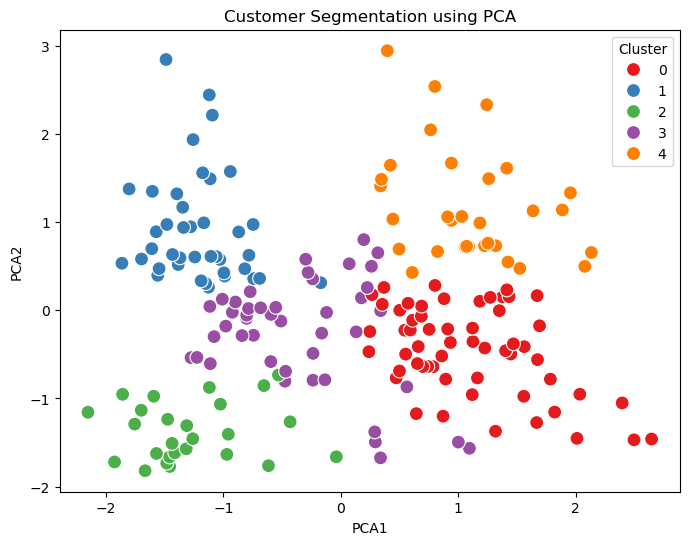

In [46]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    data=df,
    s=100
)

plt.title("Customer Segmentation using PCA")
plt.show()

#### Step 24: t-SNE Visualization 

In [47]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

tsne_features = tsne.fit_transform(X_scaled)

df["TSNE1"] = tsne_features[:,0]
df["TSNE2"] = tsne_features[:,1]

#### plot

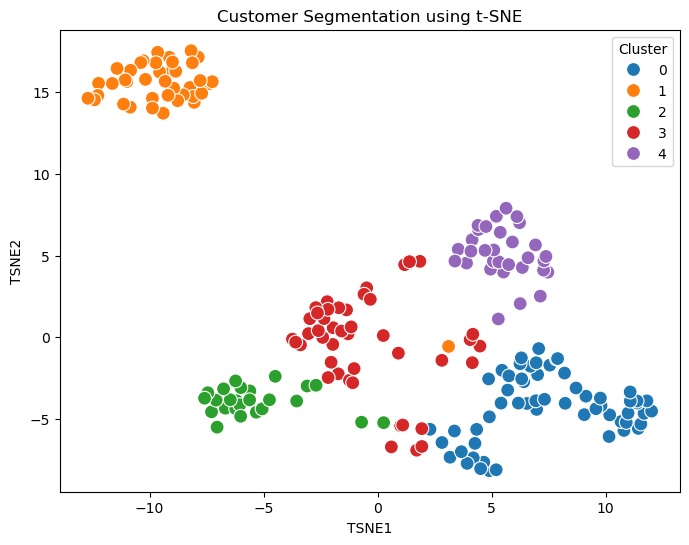

In [48]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="TSNE1",
    y="TSNE2",
    hue="Cluster",
    palette="tab10",
    data=df,
    s=100
)

plt.title("Customer Segmentation using t-SNE")
plt.show()

#### Key Insights

##### Customers were grouped into 5 distinct clusters based on Age, Annual Income, and Spending Score.
##### High-income customers show different spending behaviors, forming separate clusters.
##### PCA and t-SNE effectively reduced the data into two dimensions for visualization.
##### Clustering can help businesses understand customer behavior and improve targeted marketing.